# Credit EWS - Analysis Notebook
Reads all scores from Postgres and visualises the early warning system output.

**Sections:**
1. Setup & DB Connection
2. EWS Rankings — Full Picture
3. Score Breakdown by Component
4. Merton Deep Dive
5. Financial Ratios Deep Dive
6. Market Signals Deep Dive
7. Top 10 At-Risk Companies

## 1. Setup & DB Connection

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import psycopg2
from dotenv import dotenv_values
from pathlib import Path

# Load env vars for DB credentials
ROOT = Path().resolve().parent
env = dotenv_values(ROOT / ".env")

# Notebook-wide style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

In [70]:
def get_conn():
    return psycopg2.connect(
        host=env["DB_HOST"], port=env["DB_PORT"],
        dbname=env["DB_NAME"], user=env["DB_USER"],
        password=env["DB_PASSWORD"]
    )

def read_table(query):
    """Run any SQL query and return a DataFrame."""
    with get_conn() as conn:
        return pd.read_sql(query, conn)

print("DB connection ready.")

DB connection ready.


In [71]:
# Pull the latest run_date's data from each table
# We always want today's scores, not stale historical runs

ews       = read_table("SELECT * FROM ews_scores       WHERE run_date = (SELECT MAX(run_date) FROM ews_scores)")
merton    = read_table("SELECT * FROM merton_scores    WHERE run_date = (SELECT MAX(run_date) FROM merton_scores)")
financial = read_table("SELECT * FROM financial_scores WHERE run_date = (SELECT MAX(run_date) FROM financial_scores)")
market    = read_table("SELECT * FROM market_scores    WHERE run_date = (SELECT MAX(run_date) FROM market_scores)")

# Sort EWS by rank so rank 1 (most at risk) is on top
ews = ews.sort_values("ews_rank").set_index("ticker")

print(f"Loaded {len(ews)} companies | Run date: {ews['run_date'].iloc[0]}")

C:\Users\BM\AppData\Local\Temp\ipykernel_15224\3190588012.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Loaded 33 companies | Run date: 2026-03-04


## 2. EWS Rankings — Full Picture
Composite score across all three models. Higher = more stressed.

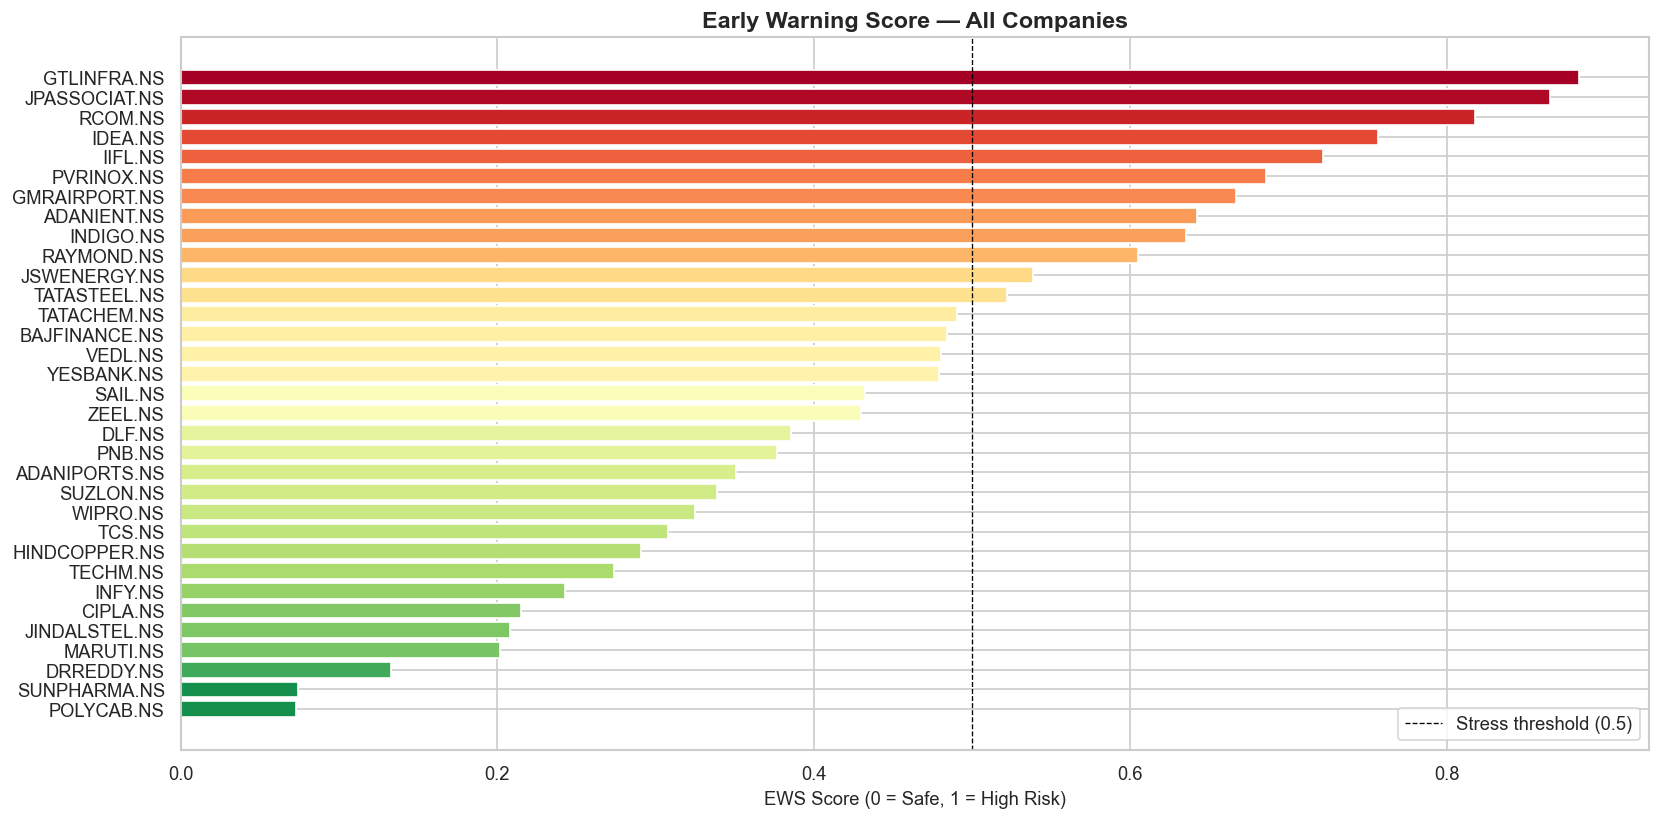

In [72]:
fig, ax = plt.subplots(figsize=(14, 7))

# Colour bars by score intensity — red = high risk, green = safe
colors = cm.RdYlGn_r(ews["ews_score"] / ews["ews_score"].max())

bars = ax.barh(ews.index[::-1], ews["ews_score"][::-1], color=colors[::-1])

ax.set_xlabel("EWS Score (0 = Safe, 1 = High Risk)", fontsize=11)
ax.set_title("Early Warning Score — All Companies", fontsize=14, fontweight="bold")
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, label="Stress threshold (0.5)")
ax.legend()
plt.tight_layout()
plt.show()

### Observations:

11 companies cross the 0.5 stress threshold. RCOM, JPASSOCIAT, GTLINFRA and IDEA cluster at the top —
all carrying known structural debt stress. Clean names (Cipla, Polycab, Infosys) correctly anchor the bottom.

## 3. Score Breakdown by Component
How much each model contributes to the final EWS score per company.

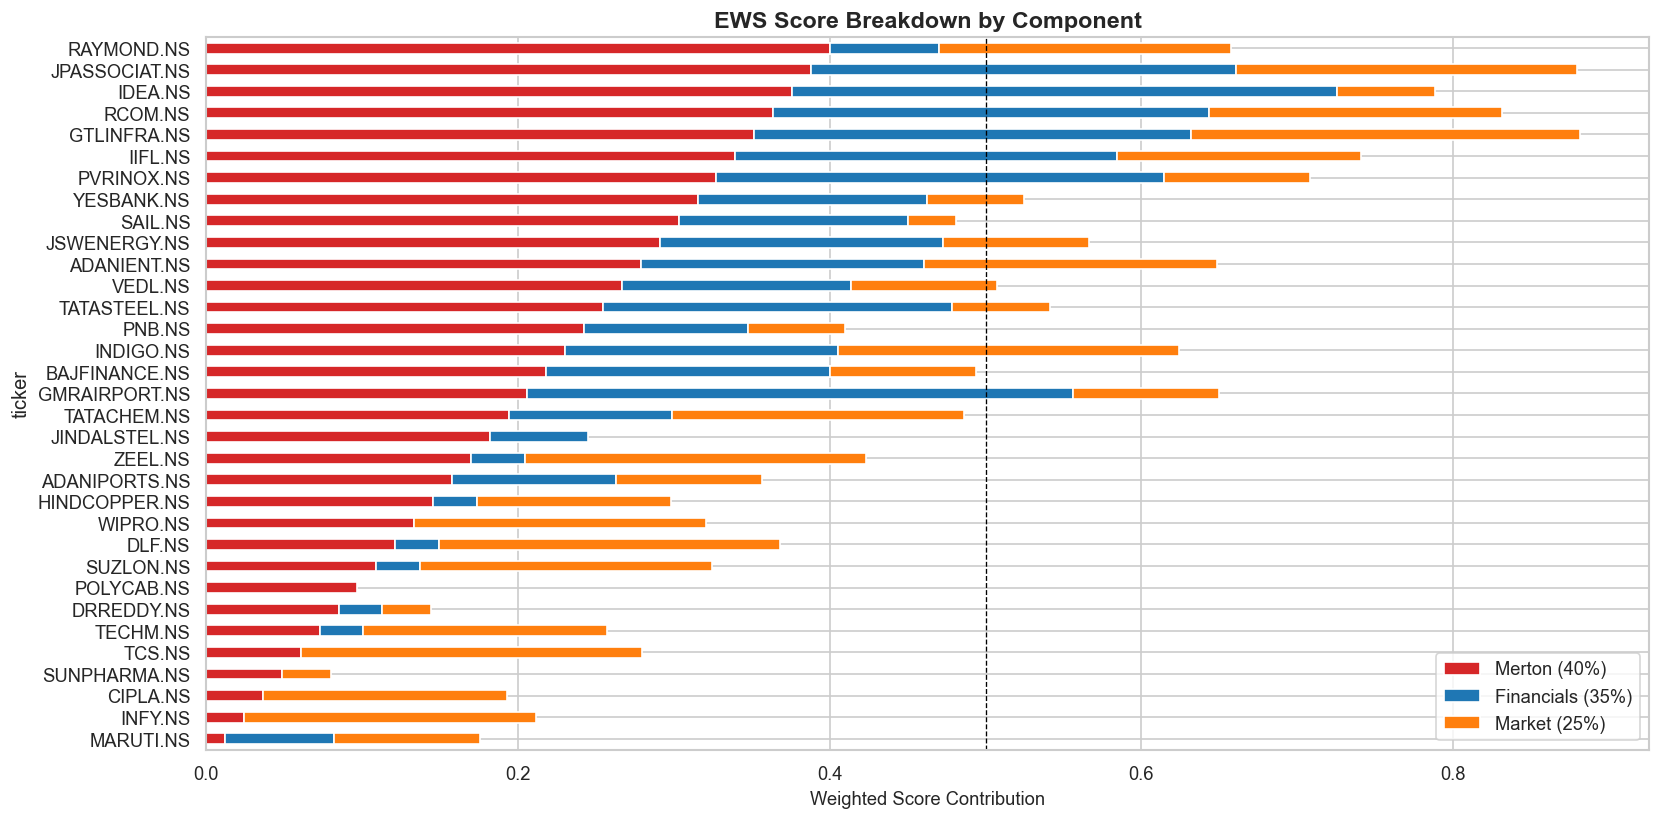

In [73]:
# Weighted contribution of each component to the final EWS score
breakdown = pd.DataFrame(index=ews.index)
breakdown["Merton (40%)"]     = ews["merton_score"]     * 0.40
breakdown["Financials (35%)"] = ews["financial_score"]  * 0.35
breakdown["Market (25%)"]     = ews["market_score"]     * 0.25

fig, ax = plt.subplots(figsize=(14, 7))

breakdown.sort_values("Merton (40%)", ascending=True).plot(
    kind="barh", stacked=True,
    color=["#d62728", "#1f77b4", "#ff7f0e"],
    ax=ax
)

ax.set_xlabel("Weighted Score Contribution", fontsize=11)
ax.set_title("EWS Score Breakdown by Component", fontsize=14, fontweight="bold")
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

### Observations:
Merton (red) dominates the top-ranked companies after percentile ranking was applied.
GMRAIRPORT is an exception — driven almost entirely by financial stress, with Merton contribution relatively low.
Market signal (orange) is the weakest contributor across the board — thresholds may need revisiting.


## 4. Merton Deep Dive
Distance to Default (DD) and Probability of Default (PD) from the structural model.

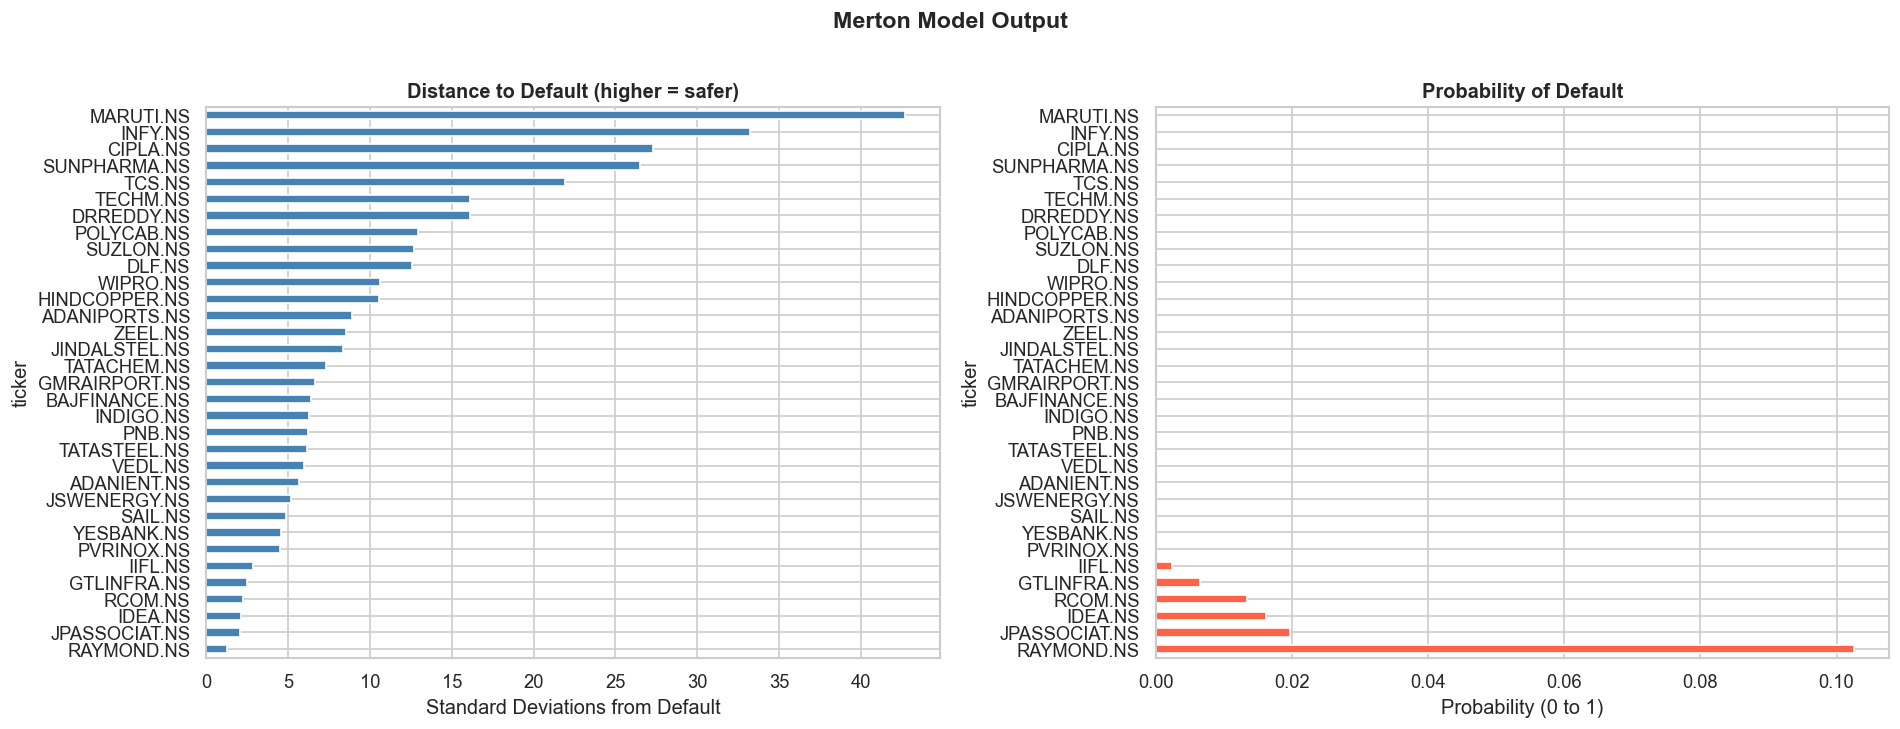

In [74]:
m = merton.set_index("ticker").reindex(ews.index)  # keep EWS sort order

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distance to Default — higher is safer (more standard deviations away from default)
m["distance_to_default"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].axvline(0, color="red", linewidth=1, linestyle="--")
axes[0].set_title("Distance to Default (higher = safer)", fontweight="bold")
axes[0].set_xlabel("Standard Deviations from Default")

# Probability of Default — direct output from Merton, already 0-1
m["probability_of_default"].sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color="tomato"
)
axes[1].set_title("Probability of Default", fontweight="bold")
axes[1].set_xlabel("Probability (0 to 1)")

plt.suptitle("Merton Model Output", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Observations:

Distance to Default confirms the ranking intuition — Raymond, IDEA, RCOM sit below 5 standard deviations.
PD chart shows meaningful spread now across distressed names after adding RCOM, JPASSOCIAT, GTLINFRA.
Previously this chart was flat for all 35 tickers on the original large-cap universe.


## 5. Financial Ratios Deep Dive
Raw ratios and their individual stress scores.

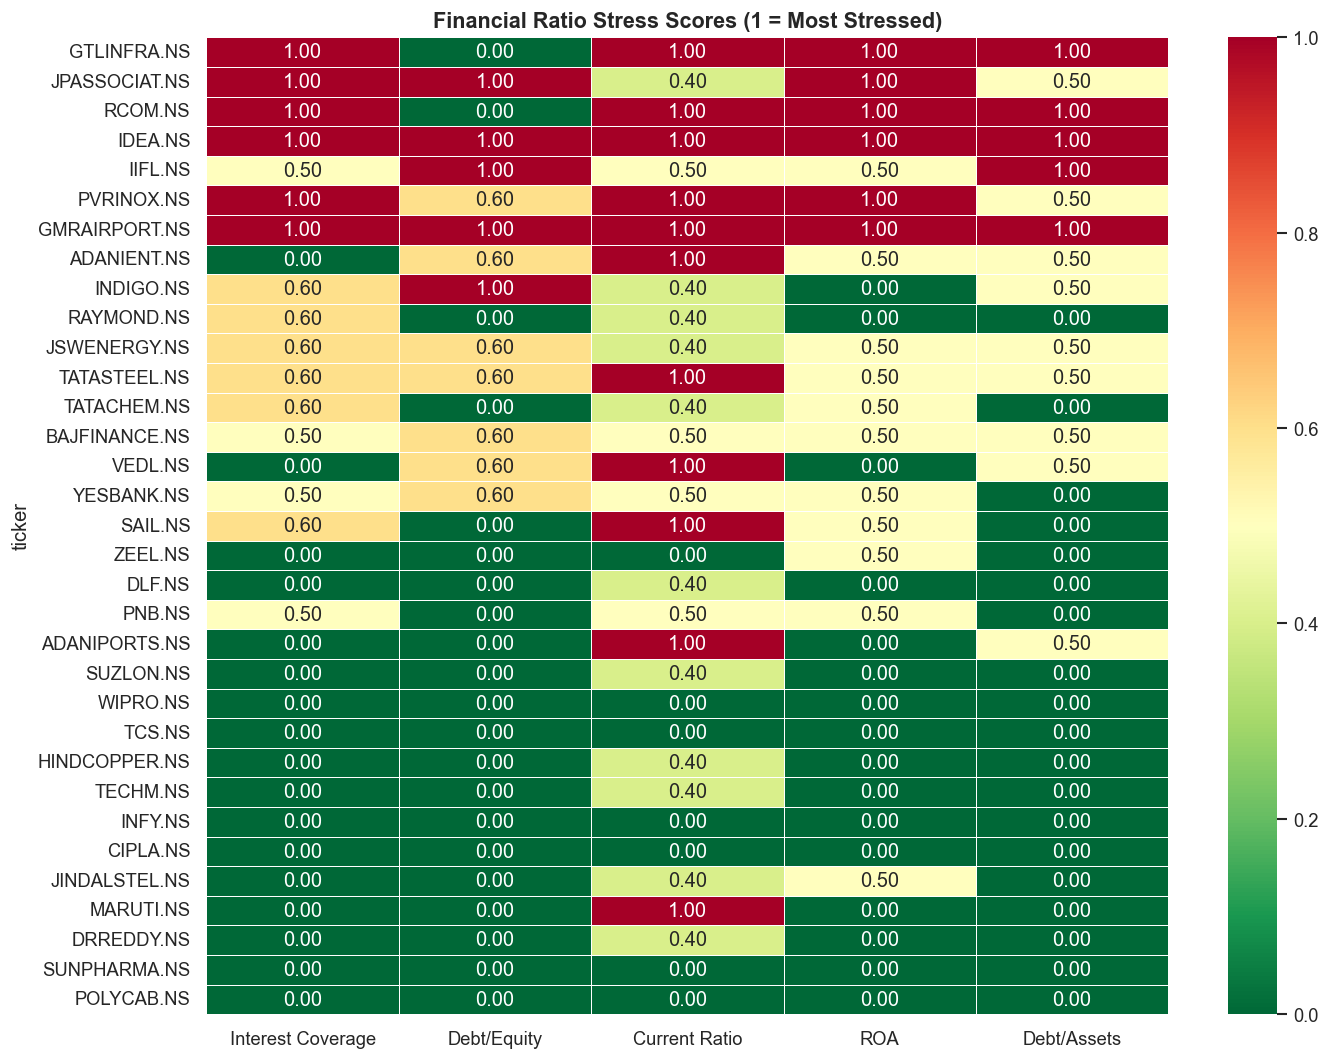

In [75]:
f = financial.set_index("ticker").reindex(ews.index)

# Heatmap of the five individual ratio scores
# Red = stressed, green = safe
score_cols = ["icr_score", "de_score", "cr_score", "roa_score", "da_score"]
labels     = ["Interest Coverage", "Debt/Equity", "Current Ratio", "ROA", "Debt/Assets"]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    f[score_cols].rename(columns=dict(zip(score_cols, labels))),
    cmap="RdYlGn_r", vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5, ax=ax
)
ax.set_title("Financial Ratio Stress Scores (1 = Most Stressed)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Observations:

RCOM, GTLINFRA, IDEA and GMRAIRPORT show red across all five ratios — broad-based financial stress.
ADANIPORTS flags on current ratio alone (infrastructure cash flow pattern) — not a full distress signal.
Pharma and IT block (bottom rows) is uniformly green as expected.

In [76]:
# Raw ratio values for context alongside the scores
raw_cols = ["interest_coverage", "debt_to_equity", "current_ratio", "roa", "debt_to_assets"]
f[raw_cols].sort_values("interest_coverage", ascending=False).round(2)

,interest_coverage,debt_to_equity,current_ratio,roa,debt_to_assets
ticker,,,,,
HINDCOPPER.NS,302.56,0.06,1.39,0.13,0.05
CIPLA.NS,155.95,0.01,4.25,0.14,0.01
MARUTI.NS,102.03,0.00,0.97,0.11,0.00
INFY.NS,91.76,0.09,2.27,0.18,0.06
TCS.NS,83.07,0.10,2.32,0.30,0.06
SUNPHARMA.NS,60.44,0.03,2.89,0.12,0.03
ZEEL.NS,29.32,0.03,6.55,0.05,0.02
DRREDDY.NS,28.14,0.14,1.92,0.11,0.09
POLYCAB.NS,20.30,0.15,2.65,0.15,0.11


## 6. Market Signals Deep Dive
Momentum, volatility regime and beta-adjusted drawdown.

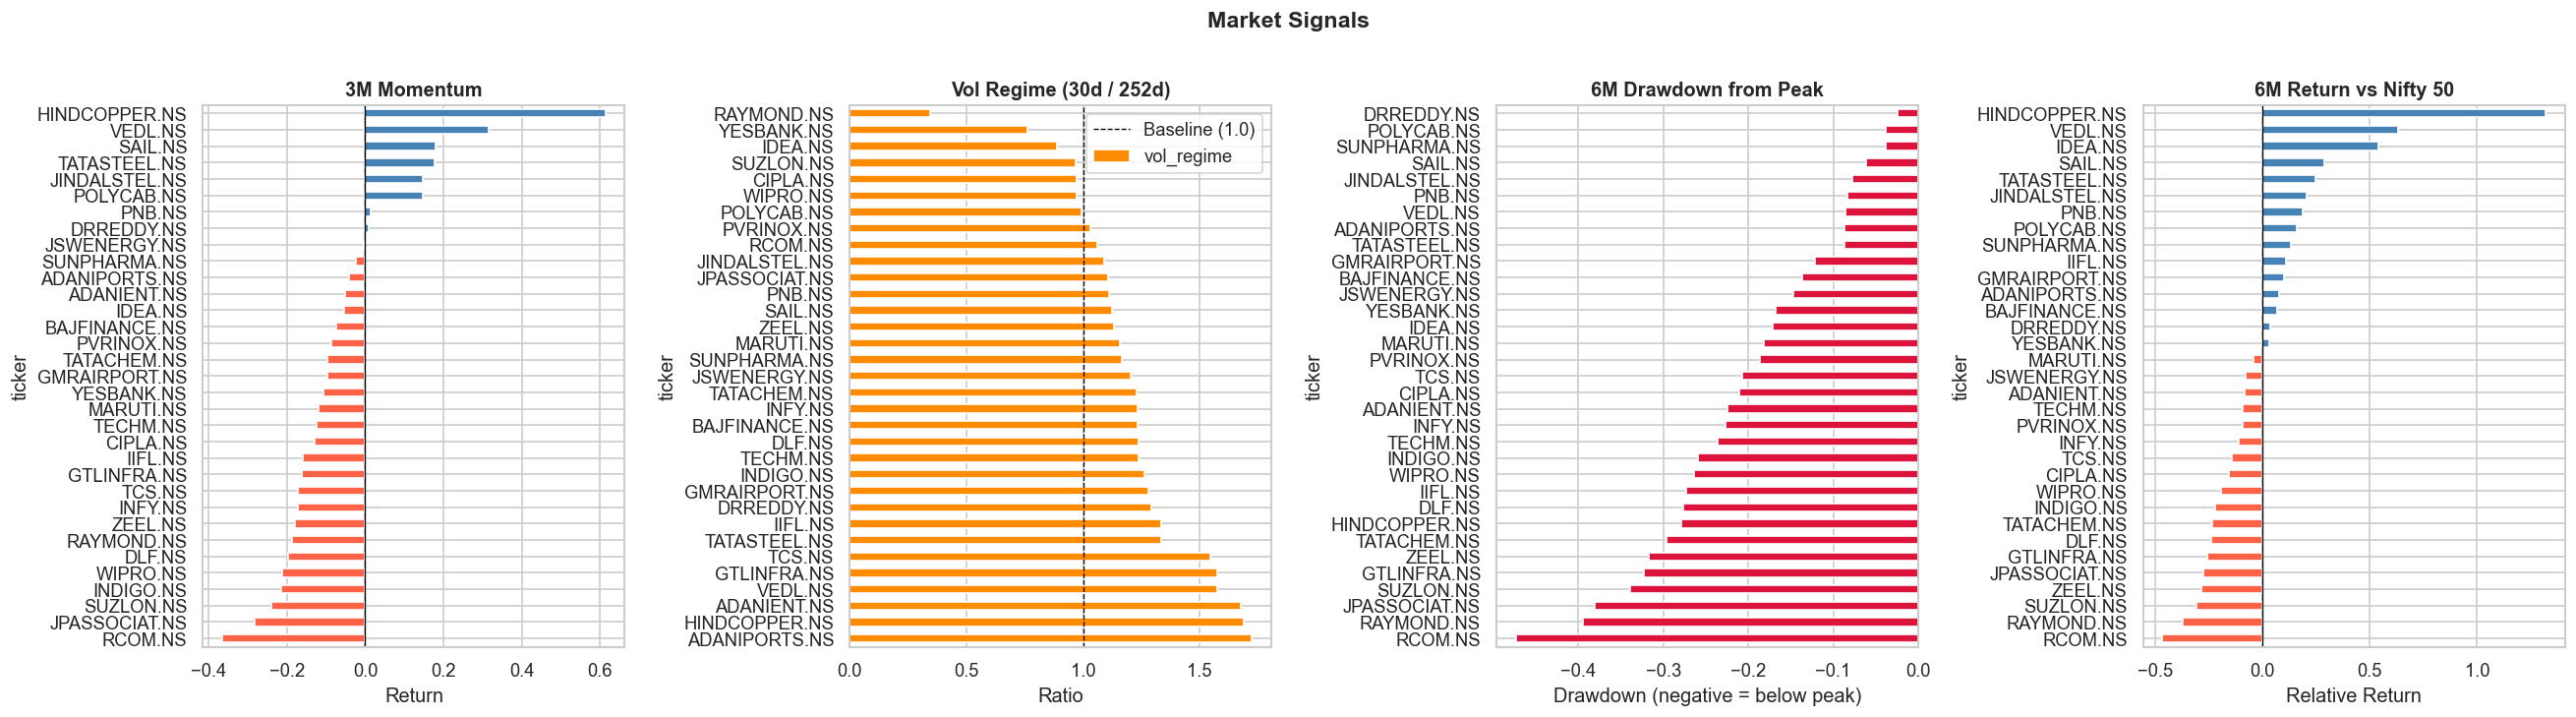

In [77]:
mk = market.set_index("ticker").reindex(ews.index)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# 3-month momentum
mk["momentum_3m"].sort_values().plot(
    kind="barh", ax=axes[0],
    color=["tomato" if v < 0 else "steelblue" for v in mk["momentum_3m"].sort_values()]
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("3M Momentum", fontweight="bold")
axes[0].set_xlabel("Return")

# Vol regime
mk["vol_regime"].sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color="darkorange"
)
axes[1].axvline(1.0, color="black", linewidth=0.8, linestyle="--", label="Baseline (1.0)")
axes[1].set_title("Vol Regime (30d / 252d)", fontweight="bold")
axes[1].set_xlabel("Ratio")
axes[1].legend()

# 6-month drawdown from recent peak
mk["drawdown_6m"].sort_values().plot(
    kind="barh", ax=axes[2], color="crimson"
)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("6M Drawdown from Peak", fontweight="bold")
axes[2].set_xlabel("Drawdown (negative = below peak)")

# Relative return vs Nifty
mk["relative_return_6m"].sort_values().plot(
    kind="barh", ax=axes[3],
    color=["tomato" if v < 0 else "steelblue" for v in mk["relative_return_6m"].sort_values()]
)
axes[3].axvline(0, color="black", linewidth=0.8)
axes[3].set_title("6M Return vs Nifty 50", fontweight="bold")
axes[3].set_xlabel("Relative Return")

plt.suptitle("Market Signals", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Observations:

Momentum shows RCOM and SUZLON deeply negative, while metals (HINDCOPPER, VEDL, TATASTEEL) are positive — sector rotation visible.
Vol regime is below 1.0 for most tickers — recent vol is calmer than the 252d norm, limiting market stress scores.
IDEA has near-zero drawdown signal despite chronic distress — price collapsed years ago and has since flatlined.


## 7. Top 10 At-Risk Companies
Full scorecard for the companies the model flags as most stressed.

In [78]:
top10 = ews.head(10)[["ews_rank", "merton_score", "financial_score", "market_score", "ews_score"]]

# Colour the table cells by value so high risk pops visually
top10.style \
    .background_gradient(cmap="RdYlGn_r", subset=["merton_score", "financial_score", "market_score", "ews_score"]) \
    .format({
        "merton_score":    "{:.3f}",
        "financial_score": "{:.3f}",
        "market_score":    "{:.3f}",
        "ews_score":       "{:.3f}",
    }) \
    .set_caption("Top 10 At-Risk Companies")

,ews_rank,merton_score,financial_score,market_score,ews_score
ticker,,,,,
GTLINFRA.NS,1,0.879,0.800,1.000,0.884
JPASSOCIAT.NS,2,0.970,0.780,0.875,0.865
RCOM.NS,3,0.909,0.800,0.750,0.818
IDEA.NS,4,0.939,1.000,0.250,0.757
IIFL.NS,5,0.848,0.700,0.625,0.722
PVRINOX.NS,6,0.818,0.820,0.375,0.686
GMRAIRPORT.NS,7,0.515,1.000,0.375,0.667
ADANIENT.NS,8,0.697,0.520,0.750,0.642
INDIGO.NS,9,0.576,0.500,0.875,0.635


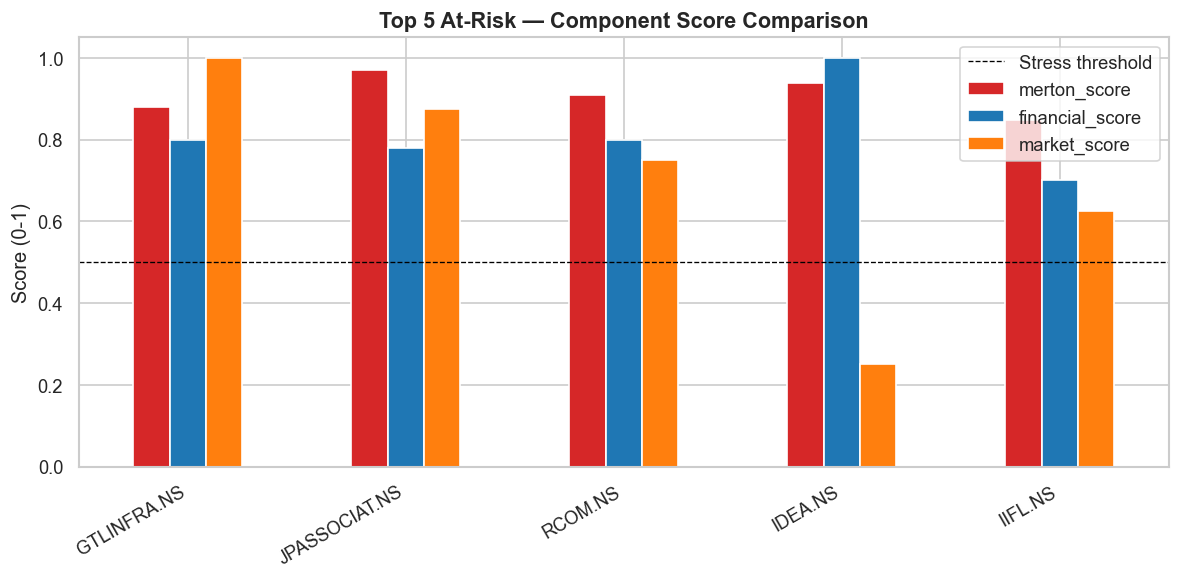

In [79]:
# Radar-style comparison of the top 5's component scores
top5 = ews.head(5)[["merton_score", "financial_score", "market_score"]]

fig, ax = plt.subplots(figsize=(10, 5))
top5.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4", "#ff7f0e"])

ax.set_title("Top 5 At-Risk — Component Score Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Score (0-1)")
ax.set_xlabel("")
ax.set_xticklabels(top5.index, rotation=30, ha="right")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Stress threshold")
ax.legend()
plt.tight_layout()
plt.show()

### Observations:

All top 5 companies have Merton and Financial scores above 0.5 — two independent models agreeing raises conviction.
IDEA is the outlier with market score of 0.0 — a known limitation where chronic price collapse looks like stability to momentum-based signals.